# Data Imputation Notebook

Note: This notebook expects the unified dataset at `data/processed/main_dataframe.csv`. Run the database processing notebook or the processing script first.

## Variables

For the data imputation process we will focus on the following variables:
- PM2.5 (μg/m³): material particulado menor a 2.5 micrómetros.
- NO₂ (ppb): dióxido de nitrógeno.
- CO (ppm): monóxido de carbono.
- NO (ppb): monóxido de nitrógeno.
- NOx (ppb): suma de NO y NO₂.

And the following stations:
- NO y CE - Monterrey
- NE - San Nicolás de los Garza
- SE - Guadalupe
- NE2 - Apodaca
- SO - Santa Catarina
- NO2 - García

In [1]:
# Imports and setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn (iterative imputer)
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


## Load dataset and isolate selected variables/stations

This section loads the unified dataset and isolates only the variables and stations listed above. It follows the same conventions as the other notebooks (parse_dates, replace -9999 with NaN).


In [2]:
# Define target pollutants from Jankdown (normalize names to match dataset columns)
pollutants_Jankdown = ["PM2.5", "NO₂", "CO", "NO", "NOx","O3"]
normalize_map = {"NO₂": "NO2", "NOx": "NOX"}
pollutants = [normalize_map.get(p, p) for p in pollutants_Jankdown]

# Define target stations and corresponding station codes
stations_Jankdown = [
    "NO y CE - Monterrey",
    "NE - San Nicolás de los Garza",
    "SE - Guadalupe",
    "NE2 - Apodaca",
    "SO - Santa Catarina",
    "NO2 - García",
]

# Map station labels from Jankdown to station_code values used in the main dataset
station_codes_map = {
    "NO y CE - Monterrey": ["NO", "CE"],
    "NE - San Nicolás de los Garza": ["NE"],
    "SE - Guadalupe": ["SE"],
    "NE2 - Apodaca": ["NE2"],
    "SO - Santa Catarina": ["SO"],
    "NO2 - García": ["NO2"],
}

target_station_codes = sorted({code for name in stations_Jankdown for code in station_codes_map.get(name, [])})

# Load dataset (same settings as in exploration notebook)
data_path = os.path.join("..", "data", "processed", "main_dataframe.csv")
df = pd.read_csv(
    data_path,
    parse_dates=["date"],
    engine="pyarrow"
)

# Treat sentinel missing values
df.replace(-9999, np.nan, inplace=True)

# Validate and select pollutant columns that exist
available_pollutants = [c for c in pollutants if c in df.columns]
missing_pollutants = [c for c in pollutants if c not in df.columns]
if missing_pollutants:
    print(f"Warning: the following pollutant columns were not found and will be skipped: {missing_pollutants}")

# Filter by station codes and keep only the relevant columns
keep_cols = ["date", "station_code"] + available_pollutants
subset = df[df["station_code"].astype(str).isin(target_station_codes)][keep_cols].copy()

# Sort by date for readability
if "date" in subset.columns:
    subset.sort_values("date", inplace=True)

# Save isolated subset
output_dir = os.path.join("..", "data", "processed")
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "pre_imputation_subset.csv")
subset.to_csv(output_file, index=False)

print(f"Saved isolated subset to: {output_file}")
print("Station codes included:", target_station_codes)
print("Columns:", keep_cols)
print("Rows:", len(subset))

# Quick preview
subset.head()


Saved isolated subset to: ..\data\processed\pre_imputation_subset.csv
Station codes included: ['CE', 'NE', 'NE2', 'NO', 'NO2', 'SE', 'SO']
Columns: ['date', 'station_code', 'PM2.5', 'NO2', 'CO', 'NO', 'NOX', 'O3']
Rows: 375587


,date,station_code,PM2.5,NO2,CO,NO,NOX,O3
0,2020-01-01,SE,54.23,NaN,NaN,NaN,NaN,NaN
35073,2020-01-01,CE,60.91,NaN,NaN,NaN,NaN,NaN
52609,2020-01-01,NO,70.81,NaN,NaN,NaN,NaN,NaN
70146,2020-01-01,SO,59.26,NaN,NaN,NaN,NaN,NaN
87683,2020-01-01,NO2,86.93,NaN,NaN,NaN,NaN,NaN


## Missing Data Analysis 

In [3]:
# Missingness analysis setup

DATA_IN = os.path.join("..","data","processed","pre_imputation_subset.csv")
REPORTS = os.path.join("..","reports")
TABLES  = os.path.join(REPORTS, "tables")
FIGS    = os.path.join(REPORTS, "figures")
os.makedirs(TABLES, exist_ok=True)
os.makedirs(FIGS, exist_ok=True)

df = pd.read_csv(DATA_IN, parse_dates=["date"]).sort_values(["station_code","date"])
value_cols = [c for c in df.columns if c not in ["date","station_code"]]

# % faltantes por contaminante (global)
miss_pollutant = df[value_cols].isna().mean().sort_values(ascending=False)*100
miss_pollutant.to_csv(os.path.join(TABLES,"missing_by_pollutant.csv"))
print("Missing % by pollutant:\n",miss_pollutant)



Missing % by pollutant:
 NOX      31.963300
PM2.5    18.338494
NO2      17.423127
NO       15.900710
O3       13.796803
CO       11.443687
dtype: float64


In [4]:
miss_station_poll = (df.groupby("station_code")[value_cols]
                       .apply(lambda g: g.isna().mean()*100)
                       .sort_index())
miss_station_poll.to_csv(os.path.join(TABLES,"missing_by_station_pollutant.csv"))
print("Missing % by station and pollutant:\n",miss_station_poll.head(10))



Missing % by station and pollutant:
                   PM2.5        NO2         CO         NO        NOX         O3
station_code                                                                  
CE            13.266390   5.836764   2.934218   9.825437  21.299626   7.170669
NE             7.653470  21.263158  11.336749  14.323242  37.034001  22.856078
NE2           25.698688  25.143464  15.699061  24.962737  40.024594  22.298405
NO            44.140771  23.183546  26.145763  19.308443  35.211268  24.124376
NO2           14.377806  14.375943   2.675461  10.167123  24.992082   6.509791
SE            13.446850  21.118522   8.629234  23.642833  37.268527   3.887999
SO             9.763524  11.024357  12.688658   9.057457  27.902720   9.720562


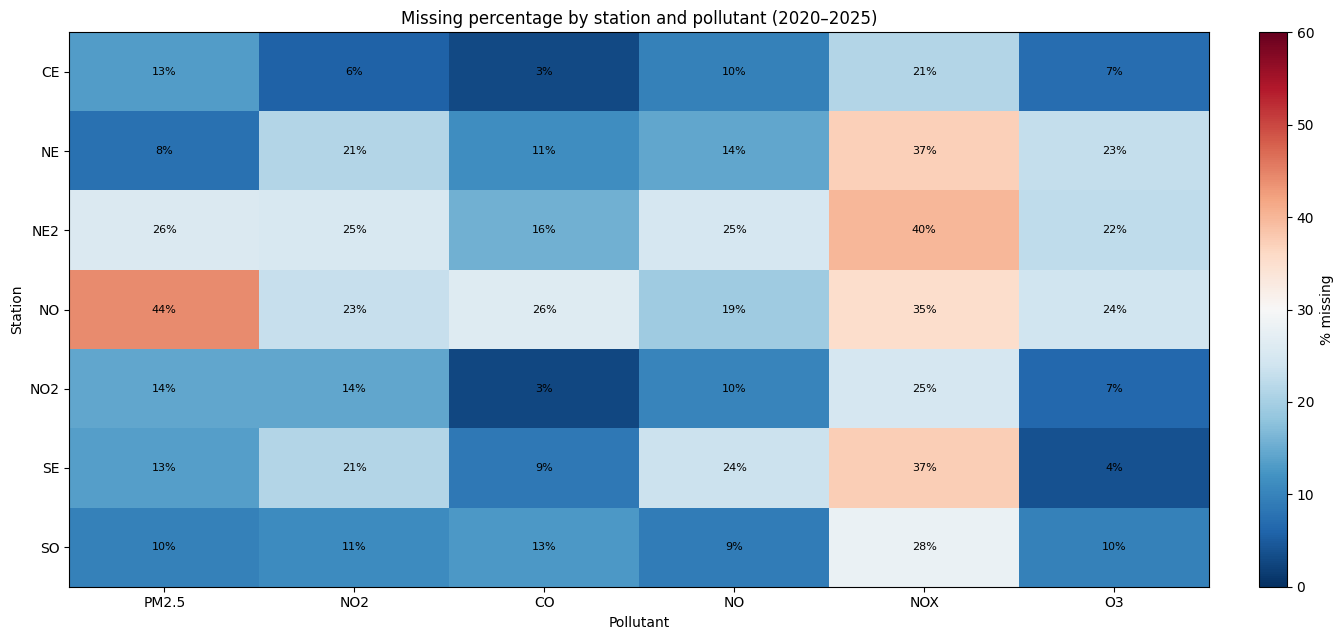

In [5]:
from matplotlib.colors import PowerNorm

# Expected columns in miss_station_poll: ["PM2.5", "NO2", "CO", "NO", "NOX"]
cols_order = ["PM2.5", "NO2", "CO", "NO", "NOX", "O3"]

# Reindex columns to a consistent order (missing ones will be added as NaN)
miss = miss_station_poll.copy().reindex(columns=cols_order)

# basic heatmap (continuous 0–100 scale)
# Rows = stations, Columns = pollutants, Color = % missing
n_rows, n_cols = miss.shape

# Figure size scales with the number of stations/columns
fig_w = max(8, 1.6 * n_cols + 4)
fig_h = max(5, 0.5 * n_rows + 3)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# imshow with default colormap; values expected in 0–100
im = ax.imshow(miss.values, aspect="auto",
               cmap="RdBu_r",
               norm=PowerNorm(gamma=1, vmin=0, vmax=60)) 

# Axis ticks and labels
ax.set_xticks(range(n_cols))
ax.set_xticklabels(miss.columns, rotation=0, ha="center")
ax.set_yticks(range(n_rows))
ax.set_yticklabels(miss.index)

ax.set_xlabel("Pollutant")
ax.set_ylabel("Station")
ax.set_title("Missing percentage by station and pollutant (2020–2025)")

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("% missing")

# annotate each cell with the rounded value
for i in range(n_rows):
    for j in range(n_cols):
        val = miss.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=8)

plt.tight_layout()

# Save figure
REPORTS = os.path.abspath(os.path.join("..", "reports"))  # Ensure it's relative to the project root

FIGS = os.path.join(REPORTS, "figures")


os.makedirs(FIGS, exist_ok=True)

plt.savefig(os.path.join(FIGS, "missing_heatmap.png"), dpi=150)



This heatmap shows the percentage of missing observations for each station × pollutant pair over 2020–2025. Rows are stations, columns are pollutants, and colors encode the missing share (0–100%). CO is generally well recorded, while NOx has consistently higher gaps. Station NO has a particularly large gap in PM2.5, and moderate gaps for CO and NOx . Stations like CE show strong completeness across pollutants, making them good anchors for cross-station imputation.

In [6]:
## Gap statistics
def nan_runs(s: pd.Series):
    arr = s.isna().to_numpy()
    runs, count = [], 0
    for v in arr:
        if v: count += 1
        elif count>0: runs.append(count); count=0
    if count>0: runs.append(count)
    return runs

rows = []
for st, g in df.groupby("station_code"):
    g = g.sort_values("date")
    for c in value_cols:
        runs = nan_runs(g[c])
        if runs:
            runs = np.array(runs)
            rows.append({
                "station_code": st, "pollutant": c,
                "n_gaps": int(len(runs)),
                "mean_gap": float(runs.mean()),
                "p50_gap": float(np.percentile(runs,50)),
                "p90_gap": float(np.percentile(runs,90)),
                "max_gap": int(runs.max())
            })
gap_stats = pd.DataFrame(rows).sort_values(["station_code","pollutant"])
gap_stats.to_csv(os.path.join(TABLES,"missing_gap_stats.csv"), index=False)
gap_stats.head(10)


,station_code,pollutant,n_gaps,mean_gap,p50_gap,p90_gap,max_gap
2,CE,CO,204,7.720588,1.0,16.0,503
3,CE,NO,1470,3.587755,2.0,8.0,66
1,CE,NO2,513,6.107212,2.0,14.8,294
4,CE,NOX,373,30.651475,2.0,12.8,8784
5,CE,O3,572,6.729021,2.0,9.0,501
0,CE,PM2.5,1036,6.873552,1.0,13.0,432
8,NE,CO,268,22.705224,1.0,9.3,3957
9,NE,NO,837,9.185185,3.0,14.0,720
7,NE,NO2,216,52.837963,1.0,6.5,10059
10,NE,NOX,184,108.032609,1.0,6.0,10062


To complement the missingness heatmap, we computed the distribution of contiguous missing runs (in hours) for each station–pollutant pair. For each pair we report the number of gaps (n_gaps), the mean gap length, the median (p50_gap), the 90th percentile (p90_gap), and the longest gap (max_gap). This reveals how data are missing: short, isolated gaps versus extended outages.

Short gaps (≤3–6 h) are well handled by local time-aware methods (e.g., time interpolation, MTB). Medium gaps (≈6–24 h) benefit from state-space/Kalman models that capture the 24-hour cycle. Long gaps (days to months) require cross-station information (e.g., KNN or multivariate imputation) and, in some cases, exclusion from the main comparison due to high uncertainty. In our data, some station–pollutant pairs (e.g., NE–NOx) exhibit very long outages (max_gap > 10,000 h), which we flag for careful interpretation.

In [7]:
# Install into the currently running interpreter
import sys, subprocess, pkgutil
if pkgutil.find_loader("statsmodels") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "statsmodels"])
import statsmodels as sm
print("statsmodels version:", sm.__version__)


statsmodels version: 0.14.5


## Imputation of NOX

In [8]:
# Imputation of Nox from NO and NO2
df["NOx_calc"] = df["NO"] + df["NO2"]
df["NOX_final"] = df["NOX"]  # copia
fill_mask = df["NOX"].isna() & df["NO"].notna() & df["NO2"].notna()
df.loc[fill_mask, "NOX_final"] = df.loc[fill_mask, "NOx_calc"]

before = df["NOX"].isna().mean()*100
after  = df["NOX_final"].isna().mean()*100
print(f"NOX % missing: before={before:.1f}%, after={after:.1f}%")


NOX % missing: before=32.0%, after=16.0%


The past cell reduce missingness in NOX by using a physically consistent rule: when NOX is missing but NO and NO₂ are both available, compute NOX = NO + NO₂. Keep the original NOX where it exists.

In [9]:
#save enriched version of the subset
#with NOx imputed from NO and NO2

# -------------------------
# paths (non-destructive)
# -------------------------
DATA_DIR = os.path.join("..", "data", "processed")
IN_FILE  = os.path.join(DATA_DIR, "pre_imputation_subset.csv")
OUT_FILE = os.path.join(DATA_DIR, "pre_imputation_subset_enriched_v1.csv")

REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")
os.makedirs(TABLES, exist_ok=True)

# -------------------------
# upload subset base
# -------------------------
sub = pd.read_csv(IN_FILE, parse_dates=["date"], engine="pyarrow").copy()

# Por si viniera algún centinela rezagado
sub.replace([-9999, -99, 9999], np.nan, inplace=True)

# -------------------------
# 2) harmonize minimal names (optional)
#    -> leave PM2.5/NO2/CO/NO/NOX standardized
# -------------------------
rename_map = {}
if "PM2_5" in sub.columns and "PM2.5" not in sub.columns:
    rename_map["PM2_5"] = "PM2.5"
if "NOx" in sub.columns and "NOX" not in sub.columns:
    rename_map["NOx"] = "NOX"
sub.rename(columns=rename_map, inplace=True)

# -------------------------
# 3) # Nox curation
# -NOX_final keeps measured and fills with NO+NO2 only when NOX is missing
# -NOX_source indicates the value source
# -------------------------
if all(c in sub.columns for c in ["NO", "NO2"]):
    sub["NOx_sum"] = sub["NO"] + sub["NO2"]
else:
    sub["NOx_sum"] = np.nan  # por si acaso

sub["NOX_final"] = sub["NOX"] if "NOX" in sub.columns else np.nan
fill_mask = sub.get("NOX").isna() & sub["NO"].notna() & sub["NO2"].notna() if "NOX" in sub.columns else (sub["NO"].notna() & sub["NO2"].notna())
sub.loc[fill_mask, "NOX_final"] = sub.loc[fill_mask, "NOx_sum"]

sub["NOX_source"] = np.where(
    ("NOX" in sub.columns) & sub["NOX"].notna(), "measured",
    np.where(sub["NO"].notna() & sub["NO2"].notna(), "sum_NO_NO2", "nan")
)

before = (sub["NOX"].isna().mean()*100) if "NOX" in sub.columns else np.nan
after  = sub["NOX_final"].isna().mean()*100
print(f"NOX % missing: before={before:.1f}%  after={after:.1f}%")

# -------------------------
# 4) Time period label, dates are not exact it can be adjusted if nedeed
# -------------------------
yr = sub["date"].dt.year
sub["period"] = np.select(
    [yr.isin([2020, 2021]), yr.isin([2023, 2024, 2025])],
    ["pandemic", "current"],
    default="transition"
)

# -------------------------
# 5) Select and order columns to keep for the enriched CSV
# -------------------------
# keep what you need to impute and audit
value_cols_for_impute = ["PM2.5", "NO2", "CO", "O3", "NO", "NOX_final"]
audit_cols = ["NOX_source", "period"]          # puedes añadir "NOx_sum" 
base_cols  = ["date", "station_code"]

# filter to columns that actually exist (in case some pollutant is missing)
keep = [c for c in base_cols + value_cols_for_impute + audit_cols if c in sub.columns]
enriched = sub[keep].sort_values(["station_code", "date"]).reset_index(drop=True)

# -------------------------
# 6) Save enriched CSV
# -------------------------
enriched.to_csv(OUT_FILE, index=False)
print("Enriched file save in:", OUT_FILE)

# SumJany of the enriched file
sumJany = {
    "input_file": IN_FILE,
    "output_file": OUT_FILE,
    "rows": len(enriched),
    "cols": len(enriched.columns),
    "n_imputed_from_sum": int(fill_mask.sum()),
    "nox_missing_before_%": None if np.isnan(before) else round(float(before), 1),
    "nox_missing_after_%": round(float(after), 1),
}
pd.DataFrame([sumJany]).to_csv(os.path.join(TABLES, "lineage_pre_imputation_enriched_v1.csv"), index=False)



NOX % missing: before=32.0%  after=16.0%
Enriched file save in: ..\data\processed\pre_imputation_subset_enriched_v1.csv


## Deduplication 

In [10]:
# Quick integrity checks on the enriched CSV
# 1) upload the enriched CSV
DATA_DIR = os.path.join("..","data","processed")
IN_FILE  = os.path.join(DATA_DIR, "pre_imputation_subset_enriched_v1.csv")
df = pd.read_csv(IN_FILE, parse_dates=["date"], engine="pyarrow")

print("Shape:", df.shape)
print("Columnas:", sorted(df.columns))

# 2) Define "official" value columns (we'll use NOX_final)
candidatas = ["PM2.5","NO2","CO", "O3", "NO","NOX_final"]
value_cols = [c for c in candidatas if c in df.columns]
print("value_cols:", value_cols)

# 3) quick integrity checks
dups = df.duplicated(["station_code","date"]).sum()
print("Dups station/date:", dups)
print("Date range:", df["date"].min(), "→", df["date"].max())

# 4) global coverage (% non-NaN)
cover = df[value_cols].notna().mean().mul(100).round(1)
print("Global coverage (% no-NaN):")
print(cover)


Shape: (375587, 10)
Columnas: ['CO', 'NO', 'NO2', 'NOX_final', 'NOX_source', 'O3', 'PM2.5', 'date', 'period', 'station_code']
value_cols: ['PM2.5', 'NO2', 'CO', 'O3', 'NO', 'NOX_final']
Dups station/date: 38465
Date range: 2020-01-01 00:00:00 → 2025-06-30 23:00:00
Global coverage (% no-NaN):
PM2.5        81.7
NO2          82.6
CO           88.6
O3           86.2
NO           84.1
NOX_final    84.0
dtype: float64


We found 38,465 duplicate station_code × date records, indicating multiple ingests or sensor overlaps; these must be resolved (e.g., keep the most recent calibrated record or average duplicates) to enforce one row per station-hour before imputation.

In [11]:
# Diagnostic of duplicates (does not modify the df)
cols_key  = ["station_code", "date"]
val_cols  = ["PM2.5","NO2","CO", "O3", "NO","NOX_final"]  # official value columns
aux_cols  = ["NOX_source"] if "NOX_source" in df.columns else []

dup_mask  = df.duplicated(cols_key, keep=False)
dups      = df.loc[dup_mask, cols_key + val_cols + aux_cols].sort_values(cols_key)

# 1)how many repetitions per key?
rep_counts = dups.groupby(cols_key).size().value_counts().sort_index()
print("Tamaño de grupos duplicados (cuántos registros por clave):")
print(rep_counts.head(10))

# 2)does each group have identical values (or all NaN) in the value columns?
def group_identical(g):
    # Para cada columna de valor, ¿hay >1 valor distinto (contando NaN como categoría)?
    nun = g[val_cols].nunique(dropna=False)
    return bool((nun <= 1).all())

by_key = dups.groupby(cols_key)
ident_flags = by_key.apply(group_identical)

print("\nProporción de grupos 'idénticos' (se pueden dropear):",
      ident_flags.mean().round(3))

# 3)  How many groups have conflicts (at least one column differs)?
conflict_keys = ident_flags[~ident_flags].index
print("Grupos con conflicto (primeros 5):", list(conflict_keys[:5]))

# 4) In conflict groups, which columns differ most often?
import pandas as pd
def diff_cols(g):
    nun = g[val_cols].nunique(dropna=False)
    return list(nun[nun>1].index)

conf_cols_freq = (
    by_key.apply(diff_cols)
          .loc[conflict_keys]
          .explode()
          .value_counts()
)
print("\nColumnas que más difieren en duplicados conflictivos:")
print(conf_cols_freq.head(10))

# 5) Sanidad rápida: ¿el 'period' es consistente dentro de cada grupo?
if "period" in df.columns:
    per_conf = df.loc[dup_mask, ["station_code","date","period"]].groupby(cols_key)["period"].nunique().gt(1).sum()
    print("\nGrupos con 'period' inconsistente:", per_conf)


Tamaño de grupos duplicados (cuántos registros por clave):
2    38465
Name: count, dtype: int64


C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1382628095.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ident_flags = by_key.apply(group_identical)



Proporción de grupos 'idénticos' (se pueden dropear): 0.998
Grupos con conflicto (primeros 5): [('CE', Timestamp('2023-06-11 00:00:00')), ('CE', Timestamp('2023-06-11 06:00:00')), ('NO', Timestamp('2023-07-17 17:00:00')), ('NO', Timestamp('2023-07-18 15:00:00')), ('NO2', Timestamp('2023-05-11 16:00:00'))]

Columnas que más difieren en duplicados conflictivos:
PM2.5        58
NO2          20
NOX_final    20
Name: count, dtype: int64

Grupos con 'period' inconsistente: 0


C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1382628095.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_key.apply(diff_cols)


In [12]:
# --- DEDUP con regla auditable ---
val_cols = ["PM2.5","NO2","CO","O3","NO","NOX_final"]
key_cols = ["station_code","date"]

df = df.copy()
df["__nnz__"] = df[val_cols].notna().sum(axis=1)  # conteo de no-NaN por fila
df["__meas__"] = (df.get("NOX_source") == "measured").astype(int) if "NOX_source" in df.columns else 0

# índice ganador por clave: más no-NaN, luego measured, luego orden original
winners = (df
    .sort_values(["__nnz__", "__meas__"], ascending=[False, False])  # mayor primero
    .groupby(key_cols, as_index=False)
    .head(1)
    .index
)

# filtra al conjunto ganador y limpia columnas auxiliares
df = df.loc[winners].sort_values(key_cols).drop(columns=["__nnz__","__meas__"])

# sanity check
dups_after = df.duplicated(key_cols).sum()
print("Duplicados station/date después:", dups_after)
print("Shape final:", df.shape)


Duplicados station/date después: 0
Shape final: (337122, 10)


Deduplication completed with 0 remaining station_code × date duplicates, ensuring one record per station–hour. Using the auditable rule (max non-missing across PM2.5, NO2, CO, NO, NOX_final, preferring measured NOx on ties), the final analysis panel is 337,122 × 9.

## Imputation of data 

### Gap-lenght charaterization 
For each station_code × pollutant × period, we rebuilt a complete hourly index and measured: total rows, % missing, the number of missing runs classified as short (≤ 6 h), medium (7–48 h), and long (> 48 h), plus the maximum and mean gap length in hours. This turns raw missingness into actionable structure (isolated holes vs. extended outages).

In [13]:
# --- Parameters for gap classification ---
SHORT_MAX = 6    # hours
MED_MAX   = 48   # hours

REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")
os.makedirs(TABLES, exist_ok=True)


# --- 1)Transform to long format (one 'pollutant' column, one 'value' column)
value_cols = ["PM2.5","NO2","CO","O3","NO","NOX_final"]
long = df[["station_code","date","period"] + value_cols] \
          .melt(id_vars=["station_code","date","period"],
                var_name="pollutant", value_name="value")

# --- 2) Function to measure gap lengths in each group
def gap_stats_for_group(g):
    # reindex to complete hourly grid between min and max of the group
    idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
    # Aggregate duplicate dates by mean (or choose another method if needed)
    g_agg = g.groupby("date")["value"].mean()
    s = g_agg.reindex(idx)

    isna = s.isna()
    if isna.sum() == 0:
        return pd.Series({
            "rows": int(len(s)),
            "missing_pct": 0.0,
            "n_gaps_short": 0,
            "n_gaps_med": 0,
            "n_gaps_long": 0,
            "max_gap_h": 0,
            "mean_gap_h": 0.0,
        })

    # identify consecutive blocks
    block_id = (isna != isna.shift()).cumsum()
    # size of each block
    block_len = block_id.groupby(block_id).transform("size")
    # keep lengths only where there are NaNs
    gap_len = block_len.where(isna, 0)

    # longitude (unique, in hours) per NaN block
    gap_lengths = pd.Series(gap_len[gap_len > 0]).groupby(block_id[gap_len > 0]).first()

    n_short = int((gap_lengths <= SHORT_MAX).sum())
    n_med   = int(((gap_lengths > SHORT_MAX) & (gap_lengths <= MED_MAX)).sum())
    n_long  = int((gap_lengths > MED_MAX).sum())

    return pd.Series({
        "rows": int(len(s)),
        "missing_pct": float(isna.mean() * 100),
        "n_gaps_short": n_short,
        "n_gaps_med": n_med,
        "n_gaps_long": n_long,
        "max_gap_h": int(gap_lengths.max()),
        "mean_gap_h": float(gap_lengths.mean()),
    })

# --- 3) Apply to each station_code × pollutant × period group
grp = long.groupby(["station_code","pollutant","period"], sort=False)
gap_tbl = grp.apply(gap_stats_for_group).reset_index()

# --- 4) save gap stats table
out_path = os.path.join(TABLES, "gap_stats_by_station_pollutant_period.csv")
gap_tbl.to_csv(out_path, index=False)
print("Guardado:", out_path)

print("\nTop 10 con mayor % faltante:")
print(gap_tbl.sort_values("missing_pct", ascending=False)
              .head(10)[["station_code","pollutant","period","missing_pct","n_gaps_long","max_gap_h"]])

print("\nResumen global (promedio ponderado por filas):")
w = gap_tbl["rows"]
for col in ["missing_pct","max_gap_h","mean_gap_h"]:
    print(col, "=", np.average(gap_tbl[col], weights=w).round(2))

C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1525575454.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1525575454.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1525575454.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1525575454.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\1525575454.py:19: FutureWarning:

Guardado: d:\Users\Val\Documents\GitHub\RetoMA2003b\MA2003B-Reto\reports\tables\gap_stats_by_station_pollutant_period.csv

Top 10 con mayor % faltante:
    station_code  pollutant    period  missing_pct  n_gaps_long  max_gap_h
11            NO      PM2.5   current    74.945175         12.0     4009.0
99            SE         NO  pandemic    65.874373          3.0    10239.0
36            SE        NO2  pandemic    60.698814          3.0    10239.0
120           SE  NOX_final  pandemic    60.670315          3.0    10239.0
72            NO         O3  pandemic    59.450524         11.0     3659.0
90           NE2         NO  pandemic    58.675331          4.0     5235.0
27           NE2        NO2  pandemic    58.606931          9.0     5235.0
66            NE         O3  pandemic    58.025536          1.0    10049.0
24            NE        NO2  pandemic    58.019836          1.0    10067.0
108           NE  NOX_final  pandemic    57.979936          1.0    10067.0

Resumen global (promed

Top gaps overview. Missingness is concentrated in the pandemic period for SE, NE2, and NE on nitrogen species (NO/NO₂/NOX), with 56–66% missing and extreme outages: SE max_gap_h = 10,239 h (14.0 months), NE 10,067 h (13.8 months), and NE2 5,235 h (7.2 months). In current, NO–PM₂.₅ is the worst case (74.95% missing; max_gap_h 4,009 h ≈ 5.5 months). Also notable: NO–CO in the pandemic (57.10%; 7,190 h ≈ 9.9 months). Despite these long-tail outages, the row-weighted averages indicate typical gaps are short (overall missing 16.99%, mean gap 22 h), so we will use time-aware interpolation for short runs and reserve cross-station borrowing or down-weighting/exclusion for the long-gap cases in the primary lockdown vs. present-day comparison.

In [14]:

# === Constuct routing table (routing_table_v1) ===
import os, numpy as np, pandas as pd

# thresholds (adjustable)
SHORT_MAX = 6     # hours
MED_MAX   = 48    # hours
COV_OK    = 80.0  # minimal coverage for "standard"
COV_MIN   = 60.0  # minimal coverage to include in main analysis
rt = gap_tbl.copy()
rt["coverage"] = 100.0 - rt["missing_pct"]

def decide(row):
    cov = row["coverage"]
    mx  = row["max_gap_h"]
    if cov >= COV_OK and mx <= SHORT_MAX:
        return "include_standard"      #Method A (estacional local) + B si aparece algún gap medio
    if (COV_MIN <= cov < COV_OK) or (SHORT_MAX < mx <= MED_MAX):
        return "include_conservative"  # Metodos A+B
    if cov >= COV_MIN and mx > MED_MAX:
        return "include_with_longs"    # A/B for short/medium; long gaps left NA (or D if much support)
    return "exclude"                   # for low coverage or extreme gaps)

rt["decision"] = rt.apply(decide, axis=1)

# Method codes for reporting
method_map = {
    "include_standard":     "A",
    "include_conservative": "A+B",
    "include_with_longs":   "A/B (leave long NA)",
    "exclude":              "none",
}
rt["method"] = rt["decision"].map(method_map)

# Bucketize coverage for reporting
rt["coverage_bucket"] = pd.cut(
    rt["coverage"], bins=[-0.1, 60, 80, 100], labels=["<60%", "60–80%", "≥80%"]
)

# Default safeguards (will be applied after imputation)
rt["safeguards"] = "clamp [0,P99.9]; enforce NOX≥NO, NOX≥NO2"

# filler for suggested neighbors (to be filled later)
rt["neighbors_hint"] = ""

# Save
REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")
os.makedirs(TABLES, exist_ok=True)
out_path = os.path.join(TABLES, "routing_table_v1.csv")
rt.to_csv(out_path, index=False)

# Summary for review
print("Guardado:", out_path)
print("\nConteo por decision:")
print(rt["decision"].value_counts())

print("\nMuestra (10 filas):")
print(rt.head(10)[["station_code","pollutant","period","coverage","max_gap_h","decision","method","coverage_bucket"]])


Guardado: d:\Users\Val\Documents\GitHub\RetoMA2003b\MA2003B-Reto\reports\tables\routing_table_v1.csv

Conteo por decision:
decision
include_with_longs      59
include_conservative    51
exclude                 16
Name: count, dtype: int64

Muestra (10 filas):
  station_code pollutant      period   coverage  max_gap_h  \
0           CE     PM2.5    pandemic  84.684223      432.0   
1           CE     PM2.5  transition  90.559361      117.0   
2           CE     PM2.5     current  85.425804      282.0   
3           NE     PM2.5    pandemic  93.958048      400.0   
4           NE     PM2.5  transition  95.034247       36.0   
5           NE     PM2.5     current  91.200658      359.0   
6          NE2     PM2.5    pandemic  79.782262      203.0   
7          NE2     PM2.5  transition  92.762557       57.0   
8          NE2     PM2.5     current  58.922697     2985.0   
9           NO     PM2.5    pandemic  91.586867      431.0   

               decision               method coverage_buc

This routing table operationalizes our missing-data policy into an auditable, reproducible plan for each station × pollutant × period. By combining coverage (≥80%, 60–80%, <60%) with gap length thresholds (short ≤ 6h, medium ≤ 48h, long > 48h), it assigns a clear decision—include_standard (A), include_conservative (A+B), include_with_longs (A/B, leave long gaps NA), or exclude—and records the recommended method label, coverage bucket, and default safeguards (clamp to P99.9; enforce NOX ≥ NO and NOX ≥ NO₂). This prevents ad-hoc choices, keeps the main lockdown vs. present-day comparison protected from low-quality segments, and pushes borderline cases to sensitivity analysis. The thresholds (COV_OK=80, COV_MIN=60, SHORT_MAX=6, MED_MAX=48) encode our risk tolerance and can be tuned; the resulting routing_table_v1.csv becomes the single source of truth for what’s included, how it’s imputed, and under which guardrails.

Method A (short-gap seasonal template). For each station × pollutant × period, we rebuild a complete hourly grid, detect contiguous NaN runs of length ≤ 6 h (SHORT_MAX), and fill only those short gaps using a robust climatology: the median by (month, hour), with fallbacks to the hour-of-day median and then the group’s overall median. The resulting series is stored as value_A, and A_imputed = True flags the timestamps that were filled. Medium/long gaps are intentionally left as NaN to be handled by subsequent methods (B/C). This approach is fast, auditable, and preserves diurnal/seasonal structure, though it can dampen short spikes compared to interpolation or model-based fills

In [15]:
import numpy as np
import pandas as pd

SHORT_MAX = 6  # hours

# 1) Transform to long format
value_cols = ["PM2.5","NO2","CO","O3","NO","NOX_final"]
long0 = df[["station_code","date","period"] + value_cols] \
           .melt(id_vars=["station_code","date","period"],
                 var_name="pollutant", value_name="value")

# 2) Imputation function for short gaps (Method A)
def impute_short_A(g):
    
    # Time index complete in the group's range
    idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
    s = g.set_index("date")["value"].reindex(idx)

    
    # Stational templates from OBSERVED values in the same group
    obs = g.dropna().copy()
    if obs.empty:
        out = pd.DataFrame({"date": idx, "value_A": s.values, "A_imputed": np.zeros(len(s), bool)})
    else:
        obs["hour"]  = obs["date"].dt.hour
        obs["month"] = obs["date"].dt.month
        templ_mh = obs.groupby(["month","hour"])["value"].median()     # mes × hora
        templ_h  = obs.groupby("hour")["value"].median()               # solo hora
        med_all  = float(obs["value"].median())

        
        #Identify NaN blocks and mark ONLY short gaps
        isna = s.isna()
        block_id  = (isna != isna.shift()).cumsum()
        block_len = block_id.groupby(block_id).transform("size")
        gap_len   = block_len.where(isna, 0)
        short_mask = gap_len.gt(0) & gap_len.le(SHORT_MAX)

        filled = s.copy()
        if short_mask.any():
            di = pd.DatetimeIndex(idx)
            mm = di.month
            hh = di.hour

            # Lookup con fallback: (mes,hora) -> hora -> mediana global
            def pick_val(m, h):
                v = templ_mh.get((m, h), np.nan)
                if pd.isna(v):
                    v = templ_h.get(h, np.nan)
                if pd.isna(v):
                    v = med_all
                return float(v)

            vals = [pick_val(m, h) for m, h in zip(mm[short_mask], hh[short_mask])]
            filled.loc[short_mask] = vals

        out = pd.DataFrame({
            "date": idx,
            "value_A": filled.values,
            "A_imputed": short_mask.values if obs.size else np.zeros(len(s), bool)
        })

    # labels for merging back
    out["station_code"] = g["station_code"].iloc[0]
    out["pollutant"]    = g["pollutant"].iloc[0]
    out["period"]       = g["period"].iloc[0]
    return out

# 3) Apply imputation A to each group
long_A = (long0
          .groupby(["station_code","pollutant","period"], group_keys=False)
          .apply(impute_short_A))

# 4) Summary of imputation A
n_imputed_A = int(long_A["A_imputed"].sum())
print("Valores rellenados por Método A (huecos cortos):", n_imputed_A)

#Optional: save detailed imputed long format
summary_A = (long_A.groupby(["pollutant","period"])["A_imputed"]
                    .mean().mul(100).round(2).rename("% celdas rellenadas A"))
print(summary_A.reset_index().head(10))


C:\Users\Val\AppData\Local\Temp\ipykernel_14176\2624701730.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\2624701730.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\2624701730.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\2624701730.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  idx = pd.date_range(g["date"].min(), g["date"].max(), freq="H")
C:\Users\Val\AppData\Local\Temp\ipykernel_14176\2624701730.py:16: FutureWarning:

Valores rellenados por Método A (huecos cortos): 45989
   pollutant      period  % celdas rellenadas A
0         CO     current                   0.72
1         CO    pandemic                   0.74
2         CO  transition                   1.14
3         NO     current                   1.97
4         NO    pandemic                   4.93
5         NO  transition                   3.15
6        NO2     current                   0.91
7        NO2    pandemic                   3.06
8        NO2  transition                   2.45
9  NOX_final     current                   1.17


B1 Tagging medium gaps after Method A (why it matters). This step audits what remains after short-gap fills by labeling each timestamp as medium_gap (7–48 h), long_gap (>48 h), or simply missing_after_A. It then cross-references the routing_table_v2 to find the station–pollutant–period cells that are slated to use Method B and checks whether they have neighbor stations (neighbors_hint) to support cross-station borrowing. The console summary quantifies: (i) overall shares of medium/long gaps, and (ii) how many target cells actually need Method B and have adequate neighbors. The exported gap_medium_after_A_summary.csv becomes a practical to-do list for Method B: it focuses modeling only where it’s justified, prevents wasting effort on cells without medium gaps, and flags cases lacking neighbors where a different strategy (or exclusion) is more appropriate.

In [16]:
# ===== B1: Etiquetar huecos MEDIOS (7–48 h) tras el Método A =====
import os, numpy as np, pandas as pd

SHORT_MAX = 6
MED_MAX   = 48

REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")

# long_A viene del paso anterior: columnas ['date','value_A','A_imputed','station_code','pollutant','period']

def tag_gaps_after_A(g):
    s = g.set_index("date")["value_A"]
    isna = s.isna()

    if isna.sum() == 0:
        out = g[["date"]].copy()
        out["medium_gap"]     = False
        out["long_gap"]       = False
        out["missing_after_A"]= False
    else:
        block_id  = (isna != isna.shift()).cumsum()
        block_len = block_id.groupby(block_id).transform("size")
        gap_len   = block_len.where(isna, 0)

        med_mask  = gap_len.gt(SHORT_MAX) & gap_len.le(MED_MAX)
        long_mask = gap_len.gt(MED_MAX)

        out = g[["date"]].copy()
        out["medium_gap"]      = med_mask.values
        out["long_gap"]        = long_mask.values
        out["missing_after_A"] = isna.values

    out["station_code"] = g["station_code"].iloc[0]
    out["pollutant"]    = g["pollutant"].iloc[0]
    out["period"]       = g["period"].iloc[0]
    return out

tags = (long_A
        .groupby(["station_code","pollutant","period"], group_keys=False)
        .apply(tag_gaps_after_A))

# Resumen de % de celdas que quedaron como "medium_gap" y "long_gap"
summ = (tags.groupby(["pollutant","period"])
            [["medium_gap","long_gap","missing_after_A"]]
            .mean().mul(100).round(2))
print("Resumen % (promedio sobre horas):")
print(summ.reset_index().head(12))

# Cargar routing_table_v2 para saber dónde aplica B
rt_v2 = pd.read_csv(os.path.join(TABLES, "routing_table_v2.csv"))

need_B = rt_v2["decision"].isin(["include_conservative","include_with_longs"])
rt_need = rt_v2.loc[need_B, ["station_code","pollutant","period","neighbors_hint"]].copy()
rt_need["has_neighbors"] = rt_need["neighbors_hint"].fillna("").str.len().gt(0)

# Cruce para contar celdas con hueco medio y con vecinos
# (solo nos interesa si EXISTE al menos un timestamp con medium_gap en esa celda)
cell_has_medium = (tags.groupby(["station_code","pollutant","period"])["medium_gap"]
                      .any().reset_index().rename(columns={"medium_gap":"has_medium"}))

review = (rt_need.merge(cell_has_medium, on=["station_code","pollutant","period"], how="left")
                .fillna({"has_medium": False}))

tot_needB      = len(review)
with_medium    = int(review["has_medium"].sum())
with_medium_nb = int((review["has_medium"] & review["has_neighbors"]).sum())

print("\nCeldas que potencialmente usarán Método B:")
print(f"  Total con decision que incluye B: {tot_needB}")
print(f"  De ellas, con huecos MEDIOS:      {with_medium}")
print(f"  ...y con vecinos disponibles:     {with_medium_nb}")

# Guarda una tabla rápida para reporte
out_path = os.path.join(TABLES, "gap_medium_after_A_summary.csv")
(review.assign(neighbors_count=review["neighbors_hint"].fillna("").str.split("\\|").apply(lambda x: 0 if x==[''] else len(x)))
       .to_csv(out_path, index=False))
print("Guardado:", out_path)


C:\Users\Val\AppData\Local\Temp\ipykernel_14176\229425450.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(tag_gaps_after_A))


Resumen % (promedio sobre horas):
    pollutant      period  medium_gap  long_gap  missing_after_A
0          CO     current        1.45      6.97             8.43
1          CO    pandemic        1.74     18.49            20.23
2          CO  transition        1.07      1.45             2.53
3          NO     current        1.87      4.90             6.77
4          NO    pandemic        6.65     22.84            29.48
5          NO  transition        1.63      0.08             1.71
6         NO2     current        1.61      5.17             6.79
7         NO2    pandemic        3.51     34.50            38.01
8         NO2  transition        1.68      0.08             1.76
9   NOX_final     current        1.66      4.67             6.33
10  NOX_final    pandemic        2.30     32.88            35.18
11  NOX_final  transition        1.64      0.08             1.72

Celdas que potencialmente usarán Método B:
  Total con decision que incluye B: 92
  De ellas, con huecos MEDIOS:      92

Method B (spatio-temporal neighbor fill for medium gaps). For each station × pollutant × period, this step fills only medium gaps (7–48 h) that remain after Method A by borrowing from neighboring stations at the same timestamps. Concretely: it (i) reads routing_table_v2 to target cells marked for B and with neighbors_hint, (ii) builds a wide matrix (rows = date, columns = stations) for the given pollutant and period, and (iii) for timestamps flagged as medium_gap & missing_after_A, replaces the value with the median across neighbor stations (skip-NaN per timestamp). Long gaps are not touched here. Results are stored in value_B with a boolean B_imputed flag. This design is auditable (uses an explicit neighbor list), robust (median, not mean), and time-aligned (no leakage across periods), providing a principled bridge over outages that are too long for short-gap methods yet small enough to justify spatial borrowing

In [17]:
# ===== B2: Imputación ESPACIO–TIEMPO (solo huecos MEDIOS) =====
import os, numpy as np, pandas as pd

SHORT_MAX = 6
MED_MAX   = 48

REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")

# 0) Cargamos la routing con vecinos
rt_v2 = pd.read_csv(os.path.join(TABLES, "routing_table_v2.csv"))
need_B = rt_v2["decision"].isin(["include_conservative","include_with_longs"])
rt_nb = rt_v2.loc[need_B & rt_v2["neighbors_hint"].fillna("").str.len().gt(0),
                  ["station_code","pollutant","period","neighbors_hint"]].copy()

# 1) Unimos etiquetas de gaps al resultado del método A
L = long_A.merge(
        tags[["station_code","pollutant","period","date","medium_gap","long_gap","missing_after_A"]],
        on=["station_code","pollutant","period","date"], how="left"
    ).copy()

# 2) Inicializamos columnas de salida para B
L["value_B"]   = L["value_A"]
L["B_imputed"] = False

# 3) Recorremos por (contaminante, periodo) para usar la matriz ancha de vecinos
for (pollutant, period), sub_idx in L.groupby(["pollutant","period"]).groups.items():
    keys_here = rt_nb[(rt_nb["pollutant"]==pollutant) & (rt_nb["period"]==period)]
    if keys_here.empty:
        continue

    # Matriz ancha: filas=fecha, columnas=estación, valores=contaminante
    wide = (df.loc[df["period"]==period, ["date","station_code", pollutant]]
              .pivot(index="date", columns="station_code", values=pollutant)
              .sort_index())

    # Procesamos cada estación con vecinos en este (pollutant, period)
    for _, row in keys_here.iterrows():
        sta     = row["station_code"]
        neighs  = [c for c in str(row["neighbors_hint"]).split("|") if c]
        if not neighs:
            continue

        # Máscara: esta celda, huecos MEDIOS, y que sigan NA después de A
        m = ((L["pollutant"]==pollutant) &
             (L["period"]==period) &
             (L["station_code"]==sta) &
             (L["medium_gap"]) &
             (L["missing_after_A"]))

        if not m.any():
            continue

        # Fechas a rellenar con mediana de vecinos en la MISMA hora
        dates = L.loc[m, "date"]
        neigh_vals = wide.reindex(dates)[neighs]
        med = neigh_vals.median(axis=1, skipna=True)

        # Rellenamos solo donde al menos un vecino tiene dato
        ok = med.notna().values
        if ok.any():
            idx_fill = L.index[m][ok]
            L.loc[idx_fill, "value_B"]   = med[ok].values
            L.loc[idx_fill, "B_imputed"] = True

# 4) Resumen
n_B = int(L["B_imputed"].sum())
print("Valores rellenados por Método B (huecos medios):", n_B)

summary_B = (L.groupby(["pollutant","period"])["B_imputed"]
               .mean().mul(100).round(2).rename("% celdas rellenadas B"))
print(summary_B.reset_index().head(12))


Valores rellenados por Método B (huecos medios): 26696
    pollutant      period  % celdas rellenadas B
0          CO     current                   1.45
1          CO    pandemic                   1.28
2          CO  transition                   0.30
3          NO     current                   1.71
4          NO    pandemic                   1.87
5          NO  transition                   0.54
6         NO2     current                   1.49
7         NO2    pandemic                   1.95
8         NO2  transition                   1.68
9   NOX_final     current                   1.49
10  NOX_final    pandemic                   1.51
11  NOX_final  transition                   0.56


In [18]:


REPORTS = os.path.abspath(os.path.join("..", "reports"))
TABLES  = os.path.join(REPORTS, "tables")
FIGS    = os.path.join(REPORTS, "figures")
os.makedirs(TABLES, exist_ok=True); os.makedirs(FIGS, exist_ok=True)

# 1) Consolidar A+B en value_AB (si B no puso valor, queda A)
L["value_AB"] = L["value_B"].where(~L["value_B"].isna(), L["value_A"])
L["AB_imputed"] = L["A_imputed"] | L["B_imputed"]

# 2) Resumen de faltantes residuales tras A+B
residual = (L.groupby(["pollutant","period"])["value_AB"]
              .apply(lambda s: s.isna().mean()*100)
              .round(2)
              .rename("% faltante tras A+B"))
print("Faltante residual por contaminante/periodo:")
print(residual.reset_index())

# 3) QC físico en timestamps con NO/NO2/NOX_final disponibles tras A+B
qc_groups = []
for per in L["period"].unique():
    for date in L.loc[L["period"]==per, "date"].unique()[:1]:
        pass  # no-op to ensure sets exist

# Extraemos tablas anchas por periodo con value_AB para NO, NO2, NOX_final
def wide_ab(period, var):
    tmp = L[(L["period"]==period) & (L["pollutant"]==var)][["date","station_code","value_AB"]]
    return tmp.pivot(index="date", columns="station_code", values="value_AB").sort_index()

qc_rows = []
for period in sorted(L["period"].unique()):
    W_NO   = wide_ab(period, "NO")       if (L["pollutant"]=="NO").any() else None
    W_NO2  = wide_ab(period, "NO2")      if (L["pollutant"]=="NO2").any() else None
    W_NOX  = wide_ab(period, "NOX_final") if (L["pollutant"]=="NOX_final").any() else None
    if W_NO is None or W_NO2 is None or W_NOX is None: 
        continue

    # Alineamos índices/columnas
    cols = sorted(set(W_NO.columns) & set(W_NO2.columns) & set(W_NOX.columns))
    W_NO, W_NO2, W_NOX = W_NO[cols], W_NO2[cols], W_NOX[cols]
    m = (~W_NO.isna()) & (~W_NO2.isna()) & (~W_NOX.isna())
    viol = (W_NOX < W_NO) | (W_NOX < W_NO2)
    viol = viol & m
    n_viol = int(viol.sum().sum())
    n_ok   = int(m.sum().sum())

    qc_rows.append({"period": period, "checks": n_ok, "violations": n_viol,
                    "viol_rate_%": round(100*n_viol/max(n_ok,1), 3)})

qc = pd.DataFrame(qc_rows)
qc.to_csv(os.path.join(TABLES, "qc_phys_AB.csv"), index=False)
print("\nQC físico NOX_final≥NO & ≥NO2 tras A+B:")
print(qc)


Faltante residual por contaminante/periodo:
    pollutant      period  % faltante tras A+B
0          CO     current                 6.98
1          CO    pandemic                18.95
2          CO  transition                 2.22
3          NO     current                 5.07
4          NO    pandemic                27.61
5          NO  transition                 1.16
6         NO2     current                 5.30
7         NO2    pandemic                36.06
8         NO2  transition                 0.08
9   NOX_final     current                 4.84
10  NOX_final    pandemic                33.67
11  NOX_final  transition                 1.16
12         O3     current                 3.42
13         O3    pandemic                30.20
14         O3  transition                 1.33
15      PM2.5     current                22.35
16      PM2.5    pandemic                 4.73
17      PM2.5  transition                 2.67

QC físico NOX_final≥NO & ≥NO2 tras A+B:
       period  checks 

In [19]:
# ==== Clamp físico en NOX_final (solo cuando fue imputado) + QC ====

# 1) Pivot con value_AB y AB_imputed para NO, NO2, NOX_final
P = (L[L["pollutant"].isin(["NO","NO2","NOX_final"])]
       [["station_code","period","date","pollutant","value_AB","AB_imputed"]]
       .pivot(index=["station_code","period","date"], columns="pollutant"))

val_NO   = P["value_AB"]["NO"]
val_NO2  = P["value_AB"]["NO2"]
val_NOX  = P["value_AB"]["NOX_final"]
imp_NOX  = P["AB_imputed"]["NOX_final"].fillna(False)

# 2) Violaciones donde tenemos los tres valores y NOX fue imputado
have_all = val_NO.notna() & val_NO2.notna() & val_NOX.notna()
viol     = ((val_NOX < val_NO) | (val_NOX < val_NO2)) & have_all & imp_NOX

# 3) Clamping: NOX := max(NO, NO2, NOX) SOLO en violaciones
nox_clamped = val_NOX.where(~viol, np.maximum.reduce([val_NO, val_NO2, val_NOX]))

# 4) Inyectar de vuelta a L (solo filas NOX_final)
keys = ["station_code","period","date"]
corr_df = nox_clamped.rename("value_AB_clamped").reset_index()

mask_nox = (L["pollutant"] == "NOX_final")
L_nox    = L.loc[mask_nox, keys + ["value_AB"]].merge(corr_df, on=keys, how="left")

changed_mask = L_nox["value_AB_clamped"].notna() & (L_nox["value_AB_clamped"] > L_nox["value_AB"])
n_changed = int(changed_mask.sum())

# Aplica cambio
L.loc[mask_nox, "value_AB"] = L_nox["value_AB_clamped"].fillna(L_nox["value_AB"]).values

print("NOX_final clamped (ajustes aplicados):", n_changed)

# 5) QC físico actualizado (NOX_final ≥ NO y ≥ NO2)
def wide_ab(period, var):
    tmp = L[(L["period"]==period) & (L["pollutant"]==var)][["date","station_code","value_AB"]]
    return tmp.pivot(index="date", columns="station_code", values="value_AB").sort_index()

qc_rows = []
for period in sorted(L["period"].unique()):
    W_NO   = wide_ab(period, "NO") if (L["pollutant"]=="NO").any() else None
    W_NO2  = wide_ab(period, "NO2") if (L["pollutant"]=="NO2").any() else None
    W_NOX  = wide_ab(period, "NOX_final") if (L["pollutant"]=="NOX_final").any() else None
    if W_NO is None or W_NO2 is None or W_NOX is None: 
        continue
    cols = sorted(set(W_NO.columns) & set(W_NO2.columns) & set(W_NOX.columns))
    W_NO, W_NO2, W_NOX = W_NO[cols], W_NO2[cols], W_NOX[cols]
    m = (~W_NO.isna()) & (~W_NO2.isna()) & (~W_NOX.isna())
    viol = ((W_NOX < W_NO) | (W_NOX < W_NO2)) & m
    qc_rows.append({
        "period": period,
        "checks": int(m.sum().sum()),
        "violations": int(viol.sum().sum()),
        "viol_rate_%": round(100*int(viol.sum().sum())/max(int(m.sum().sum()),1), 3)
    })

qc_after = pd.DataFrame(qc_rows)
print("\nQC físico tras clamp:")
print(qc_after)


NOX_final clamped (ajustes aplicados): 727

QC físico tras clamp:
       period  checks  violations  viol_rate_%
0     current  145028         573        0.395
1    pandemic   76675        1678        2.188
2  transition   60607          70        0.115


In [20]:

# Rutas
DATA_DIR = os.path.join("..","data","processed")
REPORTS  = os.path.abspath(os.path.join("..","reports"))
TABLES   = os.path.join(REPORTS,"tables")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(TABLES, exist_ok=True)

OUT_FILE = os.path.join(DATA_DIR, "pre_imputation_subset_AB_v1.csv")

# 1) Tabla ancha con los valores finales (A+B+clamp)
wide_vals = (L.pivot_table(index=["date","station_code","period"],
                           columns="pollutant", values="value_AB")
               .reset_index())

# 2) Tabla ancha con banderas de imputación (A o B)
wide_flags = (L.pivot_table(index=["date","station_code","period"],
                            columns="pollutant", values="AB_imputed", aggfunc="max")
                .fillna(False)
                .reset_index())
# renombra banderas con sufijo
flag_cols = [c for c in wide_flags.columns if c not in ["date","station_code","period"]]
wide_flags = wide_flags.rename(columns={c: f"{c}_AB_imputed" for c in flag_cols})

# 3) Unir y ordenar columnas
out = wide_vals.merge(wide_flags, on=["date","station_code","period"], how="left")

# Orden práctico de columnas
value_cols = [c for c in ["PM2.5","NO2","CO","O3","NO","NOX_final"] if c in out.columns]
flag_cols  = [f"{c}_AB_imputed" for c in value_cols if f"{c}_AB_imputed" in out.columns]
out = out[["date","station_code","period"] + value_cols + flag_cols].sort_values(["station_code","date"])

# 4) Guardar
out.to_csv(OUT_FILE, index=False)
print("Guardado dataset A+B (con clamp):", OUT_FILE)
print("Shape:", out.shape)

# 5) Resúmenes para el reporte
cover = out[value_cols].notna().mean().mul(100).round(2)
cover.to_csv(os.path.join(TABLES, "coverage_after_AB_v1.csv"))
print("\nCobertura % tras A+B por contaminante:")
print(cover)

imp_summary = (L.groupby(["pollutant","period"])["AB_imputed"]
                 .mean().mul(100).round(2)
                 .rename("% celdas imputadas_AB")
                 .reset_index())
imp_summary.to_csv(os.path.join(TABLES, "imputation_summary_AB_v1.csv"), index=False)
print("\nResumen % de celdas imputadas (A o B) por contaminante/periodo:")
print(imp_summary.head(12))


Guardado dataset A+B (con clamp): ..\data\processed\pre_imputation_subset_AB_v1.csv
Shape: (334493, 15)

Cobertura % tras A+B por contaminante:
pollutant
PM2.5        88.39
NO2          85.17
CO           90.29
O3           87.95
NO           88.18
NOX_final    86.06
dtype: float64

Resumen % de celdas imputadas (A o B) por contaminante/periodo:
    pollutant      period  % celdas imputadas_AB
0          CO     current                   2.17
1          CO    pandemic                   2.02
2          CO  transition                   1.44
3          NO     current                   3.68
4          NO    pandemic                   6.80
5          NO  transition                   3.69
6         NO2     current                   2.40
7         NO2    pandemic                   5.01
8         NO2  transition                   4.12
9   NOX_final     current                   2.66
10  NOX_final    pandemic                   3.24
11  NOX_final  transition                   2.97


We started with the enriched subset and "corrected" NOx using NO + NO₂ when it was missing (without altering measurements), removed duplicates by (station, date) using an auditable rule (favoring rows with more non-null values and, in case of ties, measured NOx), and created a routing table by station–pollutant–period. Using this, we applied imputation at two levels: A (local seasonal) for short gaps ≤6 hours, and B (spatial–temporal) for medium gaps of 7–48 hours using the median of neighboring stations selected based on correlation within the same period. Long gaps >48 hours were left as NA (no signals were fabricated), and as a physical safeguard, we adjusted NOX_final ≥ max(NO, NO₂) only when it was imputed. The consolidated result (A+B + clamp) was saved in `data/processed/pre_imputation_subset_AB_v1.csv`, ready to compare the pandemic period (2020–2021) with the current period (2023–2025) without information leakage between periods and with complete traceability.

## Time period separation: Pandemic period vs current period

In [21]:
import os, pandas as pd, numpy as np

# Rutas
DATA_DIR = os.path.join("..","data","processed")
REPORTS  = os.path.abspath(os.path.join("..","reports"))
TABLES   = os.path.join(REPORTS,"tables")
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(TABLES, exist_ok=True)

IN_FILE  = os.path.join(DATA_DIR, "pre_imputation_subset_AB_v1.csv")
OUT_FILE = os.path.join(DATA_DIR, "panel_JanJul_2020_2024_2025_AB_v1.csv")
LINEAGE  = os.path.join(TABLES, "lineage_panel_JanJul_2020_2024_2025_AB_v1.csv")

# 1) Cargar dataset A+B (con clamp)
ab = pd.read_csv(IN_FILE, parse_dates=["date"], engine="pyarrow").copy()

# 2) Definir ventanas (cerradas) y etiqueta period_window
windows = {
    "pandemic_JanJul2020": ("2020-01-01", "2020-07-30"),
    "baseline_JanJul2024": ("2024-01-01", "2024-07-30"),
    "current_JanJul2025":  ("2025-01-01", "2025-07-30"),
}

def label_window(ts):
    for lbl, (s,e) in windows.items():
        if pd.Timestamp(s) <= ts <= pd.Timestamp(e):
            return lbl
    return None

ab["period_window"] = ab["date"].apply(label_window)
panel = ab[ab["period_window"].notna()].copy()

# 3) Derivadas útiles
panel["year"]  = panel["date"].dt.year
panel["month"] = panel["date"].dt.month
panel["dow"]   = panel["date"].dt.dayofweek  # 0=Mon .. 6=Sun

# 4) Selección de columnas (solo las que existan)
vals = [c for c in ["PM2.5","NO2","CO","O3","NO","NOX_final"] if c in panel.columns]
flags = [c for c in [f"{v}_AB_imputed" for v in vals] if c in panel.columns]

cols = ["date","station_code","period_window","year","month","dow"] + vals + flags
panel = panel[cols].sort_values(["period_window","station_code","date"]).reset_index(drop=True)

# 5) Guardar panel
panel.to_csv(OUT_FILE, index=False)
print("Guardado panel:", OUT_FILE, " filas:", len(panel))

# 6) Ficha técnica (coberturas e imputación por ventana y contaminante)
rows = []
for win, (s,e) in windows.items():
    sub = panel[panel["period_window"] == win]
    for v in vals:
        n_total = len(sub)
        n_obs   = int(sub[v].notna().sum())
        cov_pct = round(100 * n_obs / max(n_total,1), 2)

        # % imputado entre valores presentes (evita sesgo por NA largos)
        flag = f"{v}_AB_imputed"
        if flag in sub.columns:
            n_imp_pres = int(((sub[v].notna()) & (sub[flag].fillna(False))).sum())
            imp_pct_among_values = round(100 * n_imp_pres / max(n_obs,1), 2)
        else:
            n_imp_pres = 0
            imp_pct_among_values = 0.0

        rows.append({
            "period_window": win,
            "start": s, "end": e,
            "pollutant": v,
            "rows_total": n_total,
            "rows_observed": n_obs,
            "coverage_pct": cov_pct,
            "imputed_count_among_values": n_imp_pres,
            "imputed_pct_among_values": imp_pct_among_values,
            "na_count": int(n_total - n_obs)
        })

lineage = pd.DataFrame(rows)
lineage.to_csv(LINEAGE, index=False)
print("Guardada ficha técnica:", LINEAGE)

# 7) Vistazo rápido para el reporte
print("\nCobertura % por ventana/contaminante:")
print(lineage.pivot_table(index=["period_window"], columns="pollutant", values="coverage_pct").round(2))

print("\n% Imputado (entre valores presentes) por ventana/contaminante:")
print(lineage.pivot_table(index=["period_window"], columns="pollutant", values="imputed_pct_among_values").round(2))


Guardado panel: ..\data\processed\panel_JanJul_2020_2024_2025_AB_v1.csv  filas: 99222
Guardada ficha técnica: d:\Users\Val\Documents\GitHub\RetoMA2003b\MA2003B-Reto\reports\tables\lineage_panel_JanJul_2020_2024_2025_AB_v1.csv

Cobertura % por ventana/contaminante:
pollutant               CO     NO    NO2  NOX_final     O3  PM2.5
period_window                                                    
baseline_JanJul2024  94.45  97.72  97.72      97.72  97.19  73.03
current_JanJul2025   85.35  81.14  80.78      83.10  95.04  67.49
pandemic_JanJul2020  58.74  53.39  37.14      42.75  49.87  97.01

% Imputado (entre valores presentes) por ventana/contaminante:
pollutant              CO     NO    NO2  NOX_final    O3  PM2.5
period_window                                                  
baseline_JanJul2024  2.80   3.99   3.22       4.03  2.56   7.89
current_JanJul2025   4.04   7.34   4.41       4.38  2.15   8.17
pandemic_JanJul2020  2.17  14.36  14.99       5.15  2.32   9.90


In [22]:
# === Diagnóstico por estación para cada ventana (cobertura e imputación) ===
import os, pandas as pd, numpy as np

DATA_DIR = os.path.join("..","data","processed")
REPORTS  = os.path.abspath(os.path.join("..","reports"))
TABLES   = os.path.join(REPORTS,"tables")
PANEL    = os.path.join(DATA_DIR, "panel_JanJul_2020_2024_2025_AB_v1.csv")

panel = pd.read_csv(PANEL, parse_dates=["date"], engine="pyarrow")

vals  = [c for c in ["PM2.5","NO2","CO","O3","NO","NOX_final"] if c in panel.columns]
flags = [f"{v}_AB_imputed" for v in vals if f"{v}_AB_imputed" in panel.columns]

rows = []
for (win, sta), g in panel.groupby(["period_window","station_code"]):
    n_total = len(g)
    for v in vals:
        n_obs = int(g[v].notna().sum())
        cov   = round(100*n_obs/max(n_total,1), 2)
        f     = f"{v}_AB_imputed"
        if f in g.columns:
            n_imp = int(((g[v].notna()) & (g[f].fillna(False))).sum())
            imp_pct_vals = round(100*n_imp/max(n_obs,1), 2) if n_obs>0 else 0.0
        else:
            imp_pct_vals = 0.0
        rows.append({
            "period_window": win,
            "station_code": sta,
            "pollutant": v,
            "rows_total": n_total,
            "rows_observed": n_obs,
            "coverage_pct": cov,
            "imputed_pct_among_values": imp_pct_vals
        })

by_sta = pd.DataFrame(rows)
out_path = os.path.join(TABLES, "coverage_by_station_window.csv")
by_sta.to_csv(out_path, index=False)
print("Guardado:", out_path)

# Muestra: peores 10 en NO2 y NOX_final para pandemic_JanJul2020
for pol in ["NO2","NOX_final"]:
    if pol in by_sta["pollutant"].unique():
        print(f"\nPeores 10 coberturas — {pol} — pandemic_JanJul2020")
        view = (by_sta[(by_sta["period_window"]=="pandemic_JanJul2020") &
                       (by_sta["pollutant"]==pol)]
                .sort_values("coverage_pct").head(10)
                [["station_code","coverage_pct","imputed_pct_among_values","rows_observed","rows_total"]])
        print(view.to_string(index=False))


Guardado: d:\Users\Val\Documents\GitHub\RetoMA2003b\MA2003B-Reto\reports\tables\coverage_by_station_window.csv

Peores 10 coberturas — NO2 — pandemic_JanJul2020
station_code  coverage_pct  imputed_pct_among_values  rows_observed  rows_total
          NE          0.00                      0.00              0        4666
          SE          0.00                      0.00              0        5065
          NO          0.16                      0.00              8        5063
         NE2          4.71                      4.37            206        4375
          SO         74.89                     20.35           3793        5065
         NO2         79.55                     27.13           4029        5065
          CE         93.35                      0.82           4728        5065

Peores 10 coberturas — NOX_final — pandemic_JanJul2020
station_code  coverage_pct  imputed_pct_among_values  rows_observed  rows_total
          NE          0.00                      0.00           

In [23]:
import os, pandas as pd, numpy as np

REPORTS = os.path.abspath(os.path.join("..","reports"))
TABLES  = os.path.join(REPORTS,"tables")
DATA_DIR= os.path.join("..","data","processed")

# Entradas
PANEL_IN   = os.path.join(DATA_DIR, "panel_JanJul_2020_2024_2025_AB_v1.csv")
BY_STATION = os.path.join(TABLES,   "coverage_by_station_window.csv")  # creado antes

# Salidas
MASK_OUT   = os.path.join(TABLES,   "station_inclusion_mask_v1.csv")
PANEL_MAIN = os.path.join(DATA_DIR, "panel_BALANCED_MAIN_JanJul_2020_2024_2025_AB_v1.csv")
PANEL_CONS = os.path.join(DATA_DIR, "panel_BALANCED_CONSERV_JanJul_2020_2024_2025_AB_v1.csv")

# --- 1) Cargar cobertura por estación/ventana y construir máscara
cov = pd.read_csv(BY_STATION)

windows = ["pandemic_JanJul2020","baseline_JanJul2024","current_JanJul2025"]
cov_piv = (cov
    .pivot_table(index=["station_code","pollutant"],
                 columns="period_window", values="coverage_pct")
    .reindex(columns=windows))
cov_piv = cov_piv.fillna(0.0)

# Decisiones
MAIN_TH   = 80.0
CONSERV_TH= 60.0
min_cov = cov_piv.min(axis=1)
decision = np.where(min_cov >= MAIN_TH, "MAIN",
            np.where(min_cov >= CONSERV_TH, "CONSERV", "EXCLUDE"))

mask = cov_piv.reset_index()
mask["min_coverage_across_windows"] = min_cov.values
mask["decision"] = decision
mask.to_csv(MASK_OUT, index=False)
print("Guardada máscara de inclusión:", MASK_OUT)
print(mask["decision"].value_counts())

# --- 2) Cargar panel y aplicar balanceo (por contaminante)
panel = pd.read_csv(PANEL_IN, parse_dates=["date"], engine="pyarrow")

value_cols = [c for c in ["PM2.5","NO2","CO","O3","NO","NOX_final"] if c in panel.columns]

def apply_balance(panel_df, mask_df, keep_tag):
    """keep_tag: 'MAIN' o 'CONSERV'"""
    out = panel_df.copy()
    for v in value_cols:
        # estaciones incluidas para este contaminante
        keep_sta = set(mask_df[(mask_df["pollutant"]==v) & (mask_df["decision"]==keep_tag)]["station_code"])
        # setear NA donde la estación NO esté incluida para ese contaminante
        bad = ~out["station_code"].isin(keep_sta)
        out.loc[bad, v] = np.nan
        # si existen banderas de imputación, quedan como estaban (solo informativas)
    return out

panel_main = apply_balance(panel, mask, "MAIN")
panel_cons = apply_balance(panel, mask, "CONSERV")

# Guardar
panel_main.to_csv(PANEL_MAIN, index=False)
panel_cons.to_csv(PANEL_CONS, index=False)
print("Guardados paneles balanceados:")
print("  MAIN   →", PANEL_MAIN, " filas:", len(panel_main))
print("  CONSERV→", PANEL_CONS, " filas:", len(panel_cons))

# --- 3) Chequeos rápidos: qué estaciones quedaron para NO2 y NOX_final
for tag, dfp in [("MAIN", panel_main), ("CONSERV", panel_cons)]:
    for pol in ["NO2","NOX_final"]:
        if pol not in value_cols: 
            continue
        kept = (dfp[dfp[pol].notna()]
                .groupby("station_code")[pol].size()
                .sort_values(ascending=False))
        print(f"\nEstaciones con datos ({tag}) para {pol}:")
        print(list(kept.index))


Guardada máscara de inclusión: d:\Users\Val\Documents\GitHub\RetoMA2003b\MA2003B-Reto\reports\tables\station_inclusion_mask_v1.csv
decision
EXCLUDE    25
MAIN       10
CONSERV     7
Name: count, dtype: int64
Guardados paneles balanceados:
  MAIN   → ..\data\processed\panel_BALANCED_MAIN_JanJul_2020_2024_2025_AB_v1.csv  filas: 99222
  CONSERV→ ..\data\processed\panel_BALANCED_CONSERV_JanJul_2020_2024_2025_AB_v1.csv  filas: 99222

Estaciones con datos (MAIN) para NO2:
['CE']

Estaciones con datos (MAIN) para NOX_final:
['CE', 'SO']

Estaciones con datos (CONSERV) para NO2:
['SO']

Estaciones con datos (CONSERV) para NOX_final:
[]


In [24]:
# QA MAIN — Cobertura/Imputación REAL (solo estaciones incluidas) vs Ocupación del panel
import os, pandas as pd, numpy as np

DATA_DIR = os.path.join("..","data","processed")
REPORTS  = os.path.abspath(os.path.join("..","reports"))
TABLES   = os.path.join(REPORTS,"tables")
os.makedirs(TABLES, exist_ok=True)

PANEL_MAIN = os.path.join(DATA_DIR, "panel_BALANCED_MAIN_JanJul_2020_2024_2025_AB_v1.csv")
MASK_PATH  = os.path.join(TABLES, "station_inclusion_mask_v1.csv")

main = pd.read_csv(PANEL_MAIN, parse_dates=["date"], engine="pyarrow")
mask = pd.read_csv(MASK_PATH)

vals  = [c for c in ["PM2.5","NO2","CO","O3","NO","NOX_final"] if c in main.columns]
wins  = ["pandemic_JanJul2020","baseline_JanJul2024","current_JanJul2025"]

# 1) Cobertura REAL (solo estaciones MAIN por contaminante)
rows_cov_real, rows_imp_real = [], []
for v in vals:
    keep_sta = set(mask[(mask["pollutant"]==v) & (mask["decision"]=="MAIN")]["station_code"])
    for win in wins:
        g = main[(main["period_window"]==win) & (main["station_code"].isin(keep_sta))]
        n_total = len(g)
        if n_total == 0:
            cov_pct = np.nan; imp_pct = np.nan; n_obs = 0; n_imp = 0
        else:
            present = g[v].notna()
            n_obs   = int(present.sum())
            cov_pct = round(100*n_obs/n_total, 2)
            flag    = f"{v}_AB_imputed"
            if flag in g.columns:
                n_imp = int((present & g[flag].fillna(False)).sum())
                imp_pct = round(100*n_imp/max(n_obs,1), 2) if n_obs>0 else 0.0
            else:
                n_imp, imp_pct = 0, 0.0
        rows_cov_real.append({"period_window": win, "pollutant": v, "coverage_pct_real": cov_pct})
        rows_imp_real.append({"period_window": win, "pollutant": v, "imputed_pct_real_among_values": imp_pct})

cov_real = pd.DataFrame(rows_cov_real)
imp_real = pd.DataFrame(rows_imp_real)

cov_real_out = os.path.join(TABLES, "MAIN_quality_REAL_coverage_by_window.csv")
imp_real_out = os.path.join(TABLES, "MAIN_quality_REAL_imputed_pct_by_window.csv")
cov_real.to_csv(cov_real_out, index=False)
imp_real.to_csv(imp_real_out, index=False)

# 2) Ocupación del panel (para contexto, igual que antes: incluye estaciones no-MAIN como NA)
rows_occ = []
for win, g in main.groupby("period_window"):
    n_total = len(g)
    for v in vals:
        n_obs = int(g[v].notna().sum())
        rows_occ.append({"period_window": win, "pollutant": v,
                         "coverage_pct_panel": round(100*n_obs/max(n_total,1), 2)})
occ = pd.DataFrame(rows_occ)
occ_out = os.path.join(TABLES, "MAIN_quality_PANEL_coverage_by_window.csv")
occ.to_csv(occ_out, index=False)

# 3) Mostrar lado a lado (pivotes)
print("Cobertura REAL % (solo estaciones incluidas en MAIN):")
print(cov_real.pivot_table(index="period_window", columns="pollutant", values="coverage_pct_real").round(2))

print("\n% Imputado REAL (entre valores presentes) — MAIN:")
print(imp_real.pivot_table(index="period_window", columns="pollutant", values="imputed_pct_real_among_values").round(2))

print("\nOcupación del panel % (contexto, incluye estaciones excluidas como NA):")
print(occ.pivot_table(index="period_window", columns="pollutant", values="coverage_pct_panel").round(2))

print(f"\nGuardados:\n  {cov_real_out}\n  {imp_real_out}\n  {occ_out}")


Cobertura REAL % (solo estaciones incluidas en MAIN):
pollutant                CO     NO     NO2  NOX_final     O3  PM2.5
period_window                                                      
baseline_JanJul2024  100.00  99.93  100.00      99.99  97.90  94.99
current_JanJul2025    97.01  99.15  100.00      99.73  98.46  97.10
pandemic_JanJul2020   99.92  93.11   93.35      96.68  95.76  99.81

% Imputado REAL (entre valores presentes) — MAIN:
pollutant              CO     NO   NO2  NOX_final    O3  PM2.5
period_window                                                 
baseline_JanJul2024  2.73   2.93  4.48       3.00  1.77   7.61
current_JanJul2025   1.24   9.96  4.60       4.60  1.75   2.42
pandemic_JanJul2020  0.99  10.54  0.82       6.42  1.72   7.13

Ocupación del panel % (contexto, incluye estaciones excluidas como NA):
pollutant               CO     NO    NO2  NOX_final     O3  PM2.5
period_window                                                    
baseline_JanJul2024  29.06  28.48  